# CSIRO Image2Biomass — Exploratory Data Analysis (EDA)

**Master's in Green Data Science — Practical ML**

Goal: understand the data structure, target distributions, the relationship
between metadata (NDVI, height) and biomass, and choose a correct data-splitting
strategy. Run: **Run All**.

## Contents
1. Setup and loading
2. Structure: long → wide
3. Target statistics
4. Outliers and the Total = Green+Dead+Clover constraint
5. Correlations (full matrix)
6. Metadata vs biomass (core hypothesis)
7. Group balance and split strategy
8. Sample images
9. Conclusions

## 1. Setup and loading

Paths come from `src/config.py` — no manual input required.

In [1]:
import sys
from pathlib import Path

# Add src/ to path so we can import config and eda
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").exists():  # if launched from notebooks/
    sys.path.insert(0, str(ROOT.parent / "src"))

import config
import eda

%matplotlib inline
config.ensure_dirs()
print("Project root:", config.PROJECT_ROOT)
print("labelled.csv exists:", config.LABELLED_CSV.exists())

Project root: C:\Users\Shuhrat\VsCode\image2biomass
labelled.csv exists: True


## 2. Structure: long → wide

The raw CSV is in long format: 5 rows per image (one per target). We pivot to wide: one row = one image, 5 target columns.

In [2]:
df_long = eda.load_long()
print("long format:", df_long.shape)
df_long.head()

long format: (1785, 10)


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target,image_id
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015-09-04,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000,ID1011485656
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015-09-04,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984,ID1011485656
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015-09-04,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751,ID1011485656
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015-09-04,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735,ID1011485656
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015-09-04,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750,ID1011485656


In [3]:
wide = eda.to_wide(df_long)
wide = eda.group_rare_species(wide, min_count=10)
print("wide format:", wide.shape)
print(f"{len(df_long)} rows / {len(wide)} images = {len(df_long)/len(wide):.1f} per image")
wide.head()

wide format: (357, 14)
1785 rows / 357 images = 5.0 per image


,image_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,month,Species_grouped
0,ID1011485656,train/ID1011485656.jpg,2015-09-04,Tas,Ryegrass_Clover,0.62,4.6667,0.0000,31.9984,16.2751,48.2735,16.2750,9,Ryegrass_Clover
1,ID1012260530,train/ID1012260530.jpg,2015-04-01,NSW,Lucerne,0.55,16.0000,0.0000,0.0000,7.6000,7.6000,7.6000,4,Lucerne
2,ID1025234388,train/ID1025234388.jpg,2015-09-01,WA,SubcloverDalkeith,0.38,1.0000,6.0500,0.0000,0.0000,6.0500,6.0500,9,Other
3,ID1028611175,train/ID1028611175.jpg,2015-05-18,Tas,Ryegrass,0.66,5.0000,0.0000,30.9703,24.2376,55.2079,24.2376,5,Ryegrass
4,ID1035947949,train/ID1035947949.jpg,2015-09-11,Tas,Ryegrass,0.54,3.5000,0.4343,23.2239,10.5261,34.1844,10.9605,9,Ryegrass


## 3. Target statistics

Distribution moments, skewness, kurtosis, zero fraction. High right-skew → a `log1p` transform will be needed during training.

In [4]:
eda.target_stats(wide)

,mean,std,min,q25,median,q75,max,skew,kurtosis,zero_pct
target,,,,,,,,,,
Dry_Green_g,26.625,25.401,0.00,8.800,20.800,35.083,157.984,1.751,3.912,5.042
Dry_Dead_g,12.045,12.402,0.00,3.200,7.981,17.638,83.841,1.761,4.200,11.204
Dry_Clover_g,6.650,12.118,0.00,0.000,1.424,7.243,71.786,2.842,9.068,37.815
GDM_g,33.274,24.936,1.04,16.026,27.108,43.676,157.984,1.559,3.049,0.000
Dry_Total_g,45.318,27.984,1.04,25.272,40.300,57.880,185.700,1.429,3.078,0.000


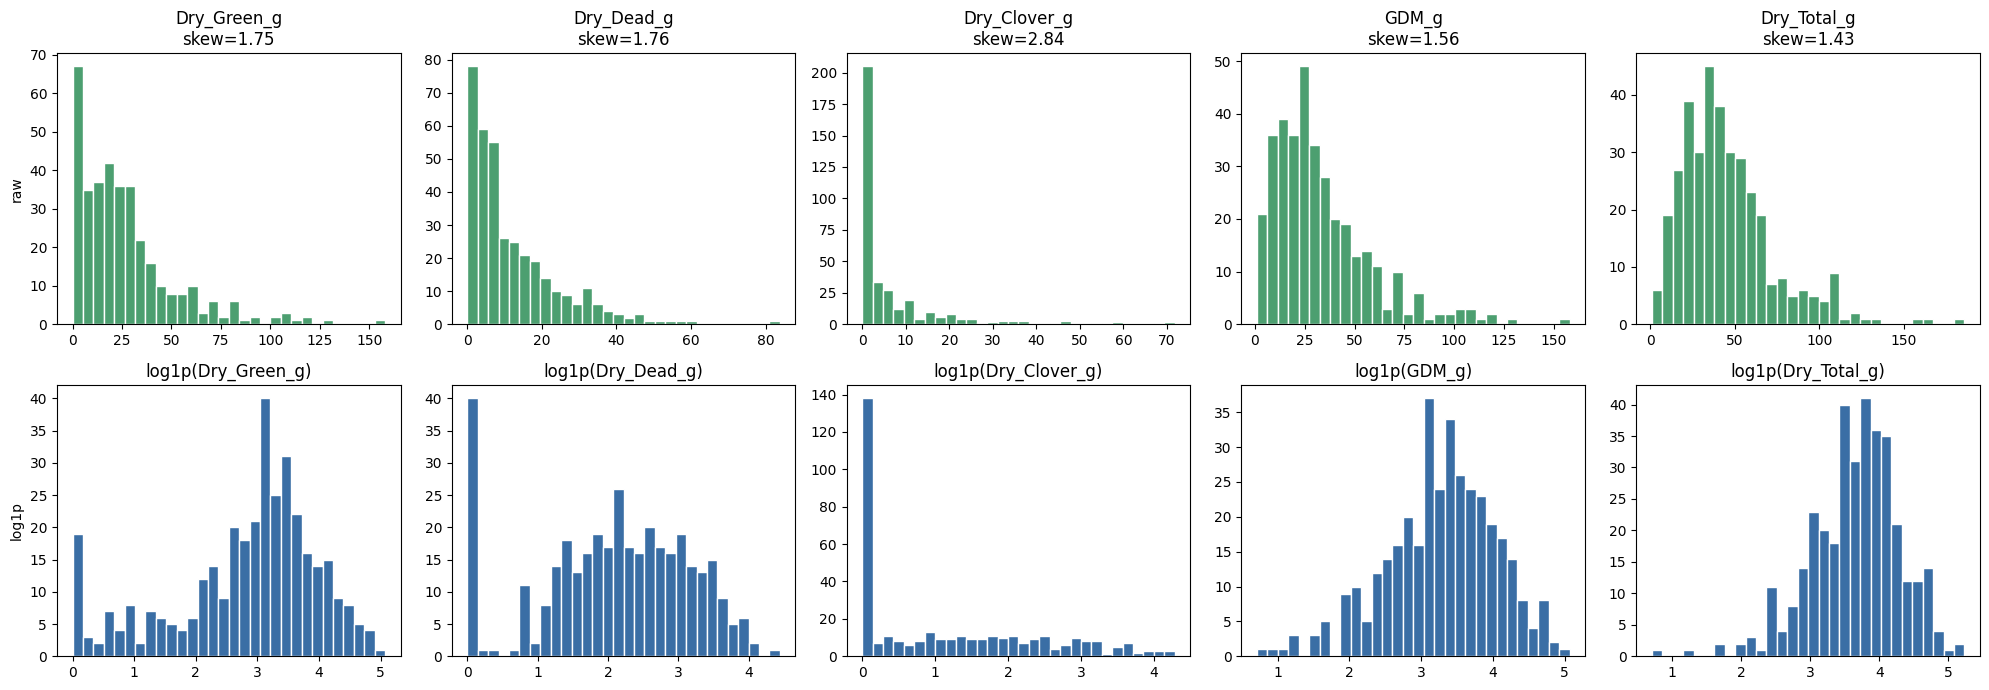

In [5]:
eda.plot_target_distributions(wide)

Top row — raw scale, bottom — `log1p`. If log noticeably symmetrizes the distribution, train regressors on `log1p(target)` and invert predictions with `expm1`.

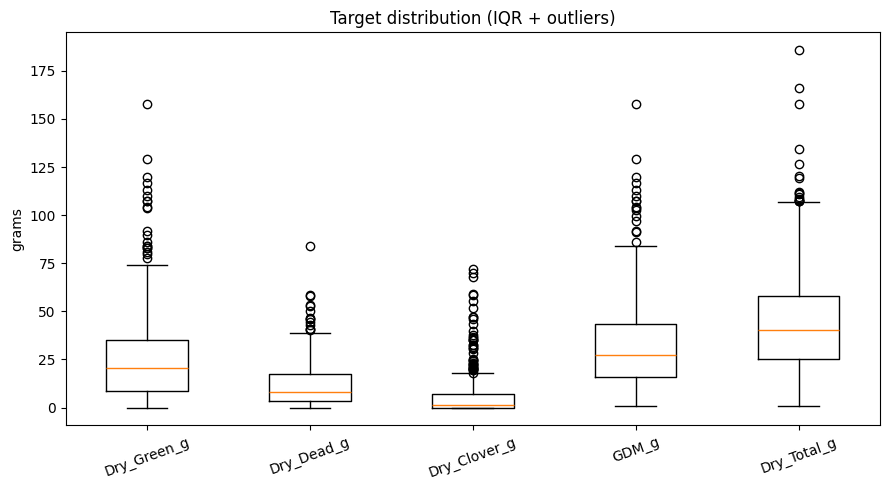

In [6]:
eda.plot_target_boxplots(wide)

## 4. Outliers and the physical constraint

IQR-rule outliers (1.5). We also check the constraint **Dry_Total_g = Dry_Green + Dry_Dead + Dry_Clover** — if it holds, we can predict the 3 components and obtain Total by summation.

In [7]:
eda.outlier_summary(wide)

,lower,upper,n_outliers
target,,,
Dry_Green_g,-30.63,74.51,20
Dry_Dead_g,-18.46,39.29,14
Dry_Clover_g,-10.86,18.11,41
GDM_g,-25.45,85.15,16
Dry_Total_g,-23.64,106.79,16


In [8]:
res = eda.check_total_constraint(wide)
print("Total = Green+Dead+Clover:")
print(f"  holds in {res['frac_ok']*100:.1f}% of cases")
print(f"  violations: {res['n_violations']}, max deviation: {res['max_abs_diff']:.3f} g")

Total = Green+Dead+Clover:
  holds in 99.7% of cases
  violations: 1, max deviation: 0.309 g


## 5. Correlations

Full matrix: targets among themselves + metadata + month. We look at (a) how related the targets are, (b) how well NDVI/height predict biomass.

In [9]:
eda.full_corr(wide)

,Dry_Green_g,Dry_Dead_g,Dry_Clover_g,GDM_g,Dry_Total_g,Pre_GSHH_NDVI,Height_Ave_cm,month
Dry_Green_g,1.000,0.096,-0.277,0.884,0.830,0.351,0.648,-0.341
Dry_Dead_g,0.096,1.000,-0.176,0.012,0.454,-0.123,-0.050,0.148
Dry_Clover_g,-0.277,-0.176,1.000,0.204,0.104,0.224,-0.160,0.363
GDM_g,0.884,0.012,0.204,1.000,0.896,0.467,0.583,-0.171
Dry_Total_g,0.830,0.454,0.104,0.896,1.000,0.361,0.497,-0.087
Pre_GSHH_NDVI,0.351,-0.123,0.224,0.467,0.361,1.000,0.238,-0.067
Height_Ave_cm,0.648,-0.050,-0.160,0.583,0.497,0.238,1.000,-0.459
month,-0.341,0.148,0.363,-0.171,-0.087,-0.067,-0.459,1.000


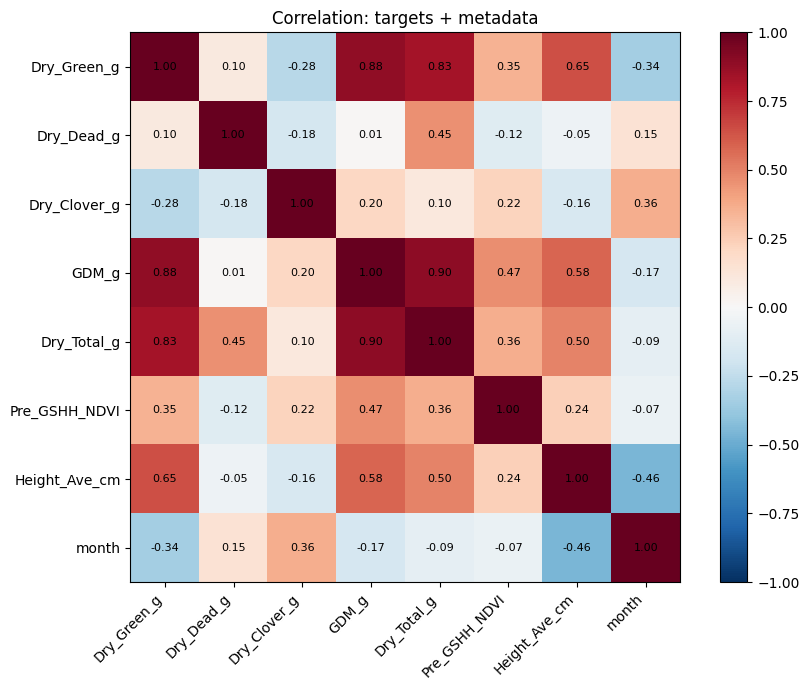

In [10]:
eda.plot_corr_heatmap(wide)

## 6. Metadata vs biomass — core hypothesis

The central scientific question of the project: **how much does the image add
beyond two cheap ground measurements (NDVI and pasture height)?**

If NDVI/height already correlate strongly with biomass, then a simple tabular
baseline on these two features will be strong, and the CNN's job is to surpass
it using pixels alone.

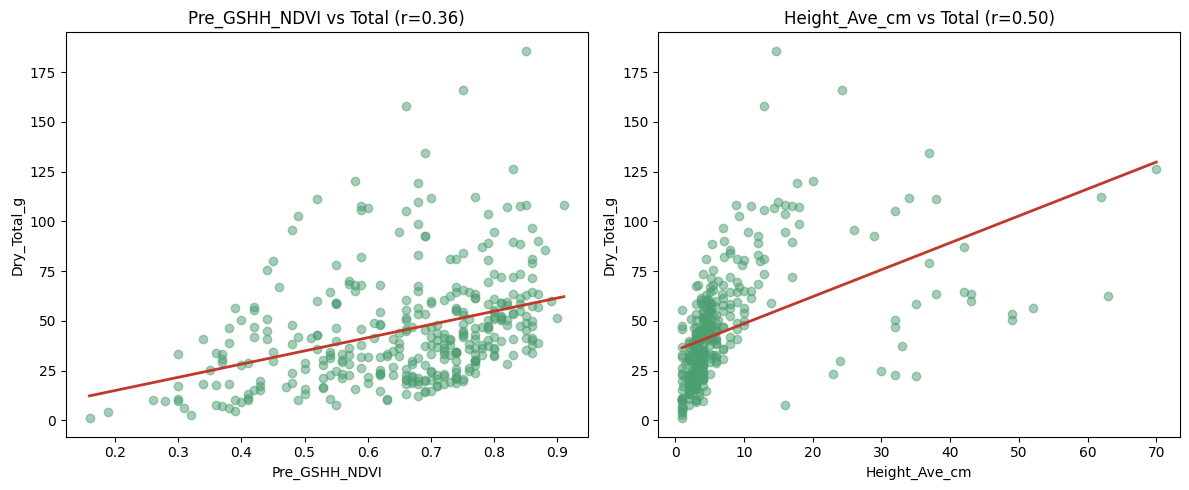

In [11]:
eda.plot_meta_scatter(wide)

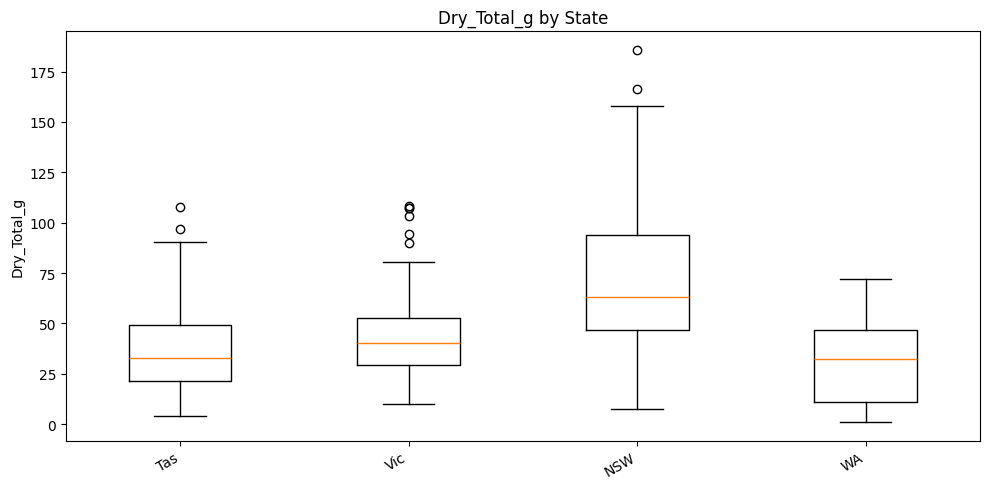

In [12]:
eda.plot_target_by_group(wide, group="State", target="Dry_Total_g")

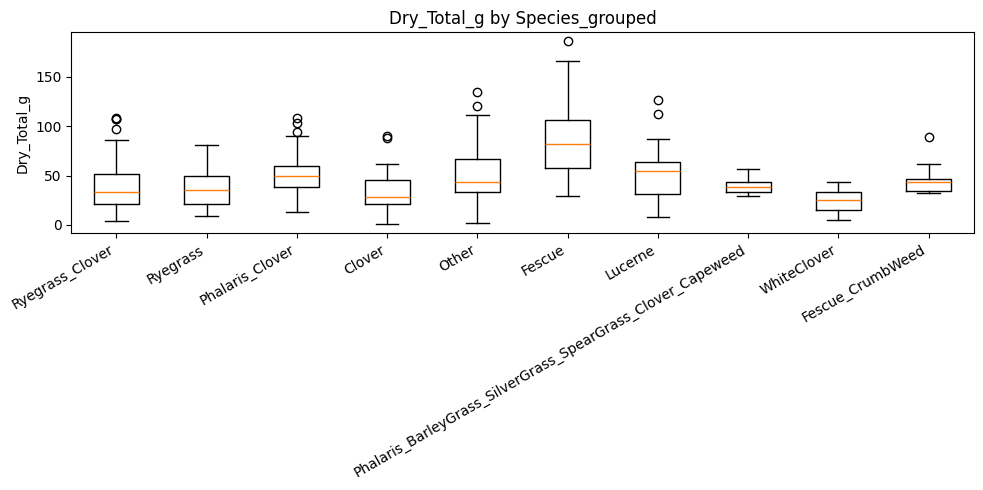

In [13]:
eda.plot_target_by_group(wide, group="Species_grouped", target="Dry_Total_g")

## 7. Group balance and split strategy

Observations from one image (5 targets) and observations from the same site are
correlated. A random split → leakage → an over-optimistic quality estimate.
We inspect group balance to choose between GroupKFold by State and
GroupShuffleSplit by image_id.

In [14]:
bal = eda.group_balance(wide)
print("Images:", bal["n_images"])
print("States:", bal["n_states"], "| by state:", bal["by_State"])
print("Species:", bal["n_species"])
print("\nSmallest state size:", min(bal["by_State"].values()))

Images: 357
States: 4 | by state: {'Tas': 138, 'Vic': 112, 'NSW': 75, 'WA': 32}
Species: 15

Smallest state size: 32


**Interpretation (fill in from the real numbers above):**
- If states < 5 or the smallest is too small → GroupKFold by State yields
  unstable folds. Use **GroupShuffleSplit by `image_id` (80/20)** stratified by
  binned `Dry_Total_g`, and keep `State` for error analysis.
- The 5 rows of one image **always** stay in the same fold (split by `image_id`).

## 8. Sample images

Visual sanity check: how the quadrats look at different biomass levels.

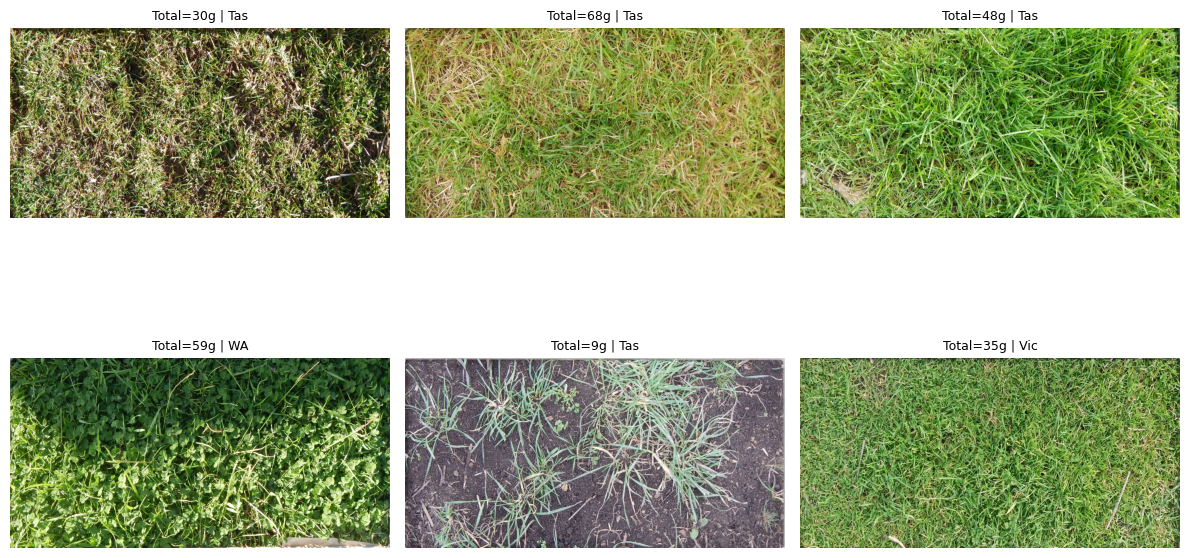

In [15]:
eda.show_sample_images(wide, n=6)

## 9. Saving and conclusions

In [16]:
wide.to_csv(config.WIDE_CSV, index=False)
print("Saved:", config.WIDE_CSV)

Saved: C:\Users\Shuhrat\VsCode\image2biomass\data\processed\labelled_wide.csv


### Targets
- All 5 targets are strongly right-skewed (skew 1.43-2.84, kurtosis 3-9).
  The hardest is **Dry_Clover_g**: skew 2.84, 37.8% zeros.
  -> Apply **log1p** when training regressors; invert predictions with expm1.
- IQR "outliers" (16-41 per target) are the **right tail of a skewed
  distribution, not errors** (genuine high-biomass cases). We do not remove them.

### Target structure
- GDM_g vs Dry_Green_g = **0.884** - strongly related but NOT duplicates.
  Confirms we predict GDM and Green separately.
- Dry_Total_g is driven mainly by green mass (Total-GDM 0.896, Total-Green 0.830).
- Dry_Clover_g is weakly/negatively related to the rest (Clover-Green -0.28).
- The constraint Total = Green+Dead+Clover holds in ~99.7% of rows.

### Metadata vs biomass (core hypothesis)
- **Height_Ave_cm** is the strongest single predictor: Green 0.65, Total 0.50.
- **Pre_GSHH_NDVI**: GDM 0.47, Total 0.36; the scatter shows heteroscedasticity
  (NDVI saturation on dense pasture).
- Together they form a strong tabular baseline, but r~0.5 leaves most of Total's
  variance unexplained. **This gap is what the image should close** - a
  quantitatively grounded motivation for the CNN.

### Seasonality and species
- month correlates with Height (-0.46), Green (-0.34), Clover (+0.36)
  -> add **month** as a tabular feature.
- Species carries signal (Fescue median ~80 g vs ~25 g for WhiteClover)
  -> useful categorical feature; rare species (<10) collapsed into "Other".

### Data and split
- 357 images, 4 imbalanced states (Tas 138 ... WA 32), 15 species.
- Strategy: **GroupShuffleSplit by image_id (80/20)** stratified by binned
  Dry_Total_g. GroupKFold by State rejected due to imbalance. State kept for
  error analysis.